In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import split
from shapely.geometry import LineString
import cartopy.io.shapereader as shpreader

In [2]:
# Load geojson files
esp = gpd.read_file("spatial files/esp.geojson")
aus = gpd.read_file("spatial files/aus.geojson")
nor = gpd.read_file("spatial files/nor.geojson")
swe = gpd.read_file("spatial files/swe.geojson")
nld = gpd.read_file("spatial files/nld.geojson")
bel = gpd.read_file("spatial files/bel.geojson")
che = gpd.read_file("spatial files/che.geojson")
hun = gpd.read_file("spatial files/Lands-of-the-Crown-of-Saint-Stephen.geojson")  # different structure
bay = gpd.read_file("spatial files/bayern.geojson") # different structure
gbr = gpd.read_file("spatial files/gbr.geojson")
usa = gpd.read_file("spatial files/usa.geojson")
den = gpd.read_file("spatial files/dk(1).json") # different structure

In [3]:
# List of gdfs
gdfs = [esp, aus, nor, swe, nld, bel, che, gbr, usa]

# List of country names
country_names = ["Spain", "Australia", "Norway", "Sweden", "Netherlands", "Belgium", "Switzerland", "U.K. of Great Britain and Northern Ireland",
                "United States of America"]

In [4]:
# Function to find the largest polygon in each gdf and append them into a new gdf
def largest_polygons(gdfs, country_names):
    results = []

    for gdf, country_name in zip(gdfs, country_names):
        # Select the row
        row = gdf.loc[gdf["name"] == country_name].iloc[0]

        # Extract geometry
        poly = row.geometry

        # Split polygon or MultiPolygon
        if poly.geom_type == "MultiPolygon":
            split_polygons = list(poly.geoms)
        else:
            split_polygons = [poly]

        # Largest polygon by area
        largest_poly = max(split_polygons, key=lambda p: p.area)

        # Create a new row 
        new_row = row.copy()
        new_row.geometry = largest_poly        

        results.append(new_row)

    # Return as a gdf
    return gpd.GeoDataFrame(results, crs=gdfs[0].crs)

In [5]:
# Apply function
largest_polygons = largest_polygons(gdfs, country_names)

# Select relevant columns
gdf = largest_polygons[["iso3", "name", "geometry"]].reset_index(drop=True)

# Add Hungary and Bayern

In [6]:
# Create new columns
hun["iso3"] ="HUN"
hun["name"] = "Hungary"
hun = hun[["iso3", "name", "geometry"]]

In [7]:
# Create new columns
bay["iso3"] ="BAY"
bay["name"] = "Bayern"
bay = bay[["iso3", "name", "geometry"]]

In [8]:
# Concat gdf with hun, bay gdfs
gdf = pd.concat([gdf, hun, bay], ignore_index=True)

# Add Denmark

In [9]:
# Select first row
dk1 = den.iloc[0] 

# Extract geometry
poly = dk1.geometry  

# Extract polygons 
split_polygons = list(poly.geoms)

# Extract number of polygons
n_splits = len(split_polygons)

# Remove country
dk2 = den[den["name"] != "Denmark"]

# Create new rows for polygons
split_gdf = gpd.GeoDataFrame(
    {
        "name": ["Denmark"] * n_splits,    
        "iso3": [f"DK{i+1}" for i in range(n_splits)],
        "geometry": split_polygons
    },
    crs=den.crs
)

# Concatenate original gdf with splitted polygons
dk3 = pd.concat([dk2, split_gdf], ignore_index=True)

# Select relevant columns
dk4 = dk3[["iso3", "name", "geometry"]]

In [10]:
# Create gdf with largest polygon
den = dk4[dk4["iso3"]=="DK1"]

In [11]:
# Concat gdf with den
gdf = pd.concat([gdf, den], ignore_index=True)

# Split Netherlands

In [12]:
# Select first row
nl1 = gdf.iloc[4]

# Extract geometry
geom = nl1.geometry  

# Split line coords
split_line = LineString([(5, 53.2), (5.85, 52.9)])

# Split the polygon into 2
split_result = split(geom, split_line)

# Remove country
nl2 = gdf[gdf["name"] != "Netherlands"]

# Create new rows for splitted polygon
split_gdf = gpd.GeoDataFrame(
    {
        "name": ["Netherlands"] * len(split_result.geoms),
        "iso3": [f"NL{i+1}" for i in range(len(split_result.geoms))],
        "geometry": list(split_result.geoms)
    },
    crs=gdf.crs
)

# Concatenate original gdf with splitted polygons
nl3 = pd.concat([nl2, split_gdf], ignore_index=True)

# Select relevant columns
nl4 = nl3[["iso3", "name", "geometry"]]

In [13]:
# Create new gdf without splitted part
nld = nl4[nl4["iso3"]=="NL1"]

In [14]:
gdf = gdf[gdf["iso3"] != "NLD"]
gdf = pd.concat([gdf, nld], ignore_index=True)

# Split England

In [15]:
# Select first row
uk1 = gdf.iloc[6]

# Extract geometry
geom = uk1.geometry  

# Split line coords
split_line = LineString([(-2.9, 56), (-3.3, 54.9)])

# Split the polygon into 2
split_result = split(geom, split_line)

# Remove country
uk2 = gdf[gdf["name"] != "U.K. of Great Britain and Northern Ireland"]

# Create new rows for splitted polygon
split_gdf = gpd.GeoDataFrame(
    {
        "name": ["U.K. of Great Britain and Northern Ireland"] * len(split_result.geoms),
        "iso3": [f"UK{i+1}" for i in range(len(split_result.geoms))],
        "geometry": list(split_result.geoms)
    },
    crs=gdf.crs
)

# Concatenate original gdf with splitted polygons
uk3 = pd.concat([uk2, split_gdf], ignore_index=True)

# Select relevant columns
uk4 = uk3[["iso3", "name", "geometry"]]

In [16]:
# Create new gdf without splitted part
eng0 = uk4[uk4["iso3"]=="UK2"]

In [17]:
# Select polygon to split
eng1 = eng0[eng0["iso3"] == "UK2"].iloc[0]
geom = eng1.geometry  

# Create another split line
split_line = LineString([(-3, 53.4), (-3, 51.5)])

# Split the polygon into 2
split_result = split(geom, split_line)

# Create new split pieces
split_gdf = gpd.GeoDataFrame(
    {
        "name": ["U.K. of Great Britain and Northern Ireland"] * len(split_result.geoms),
        "iso3": [f"UK{i+1}" for i in range(len(split_result.geoms))],
        "geometry": list(split_result.geoms)
    },
    crs=gdf.crs
)

# Concatenate original gdf with splitted polygons
eng3 = pd.concat([uk2, split_gdf], ignore_index=True)

In [18]:
# Create new gdf without splitted part
eng = eng3[eng3["iso3"] == "UK1"]

In [19]:
# Drop GBR
gdf = gdf[gdf["iso3"] != "GBR"]
# Concat gdf with eng
gdf = pd.concat([gdf, eng], ignore_index=True)

# Data

In [20]:
data = pd.read_csv("data.csv")

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country     11 non-null     object
 1   Population  11 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 308.0+ bytes


In [22]:
data

,Country,Population
0,ESPAÑA,17500000
1,AUSTRALIA,3036570
2,NORVÈGE,2000917
3,SUÈDE,4774409
4,NEDERLANDEN,4500000
5,LA BELGIQUE,6000000
6,SUISSE,2900000
7,NEGRO POPULATION,7500000
8,HONGRIE,17500000
9,BAYERN,5800000


In [23]:
# Add new row for Denmark
new_row = pd.DataFrame([["Danemark", 3300000]], columns=data.columns)
# Concatenate new row with data
df = pd.concat([data, new_row], ignore_index=True)

In [24]:
# Create new column
df["iso3"] = "ESP", "AUS", "NOR", "SWE", "NL1", "BEL", "CHE", "USA", "HUN", "BAY", "UK1", "DK1"

# Merge

In [25]:
# Merge gdf with df
gdf = pd.merge(gdf, df, on="iso3")

In [26]:
# Define mappings
mapping = {
    "NOR": "Scandinavia",
    "SWE": "Scandinavia",
    "DK1": "Scandinavia",
    "NL1": "Benelux",
    "BEL": "Benelux"
}

# Apply replacement
gdf["id"] = gdf["iso3"].replace(mapping)

In [27]:
# Custom order
custom_order = ["ESP", "AUS", "NOR", "SWE", "DK1", "BEL", "NL1", "USA", "CHE", "HUN", "BAY", "UK1"]

# Sort using the custom order
gdf["iso3"] = pd.Categorical(gdf["iso3"], categories=custom_order, ordered=True)
gdf = gdf.sort_values("iso3", ignore_index=True)

In [28]:
# Calculate centroid in meters and reproject back to EPSG:4326
gdf["centroid"] = (
    gdf.to_crs("+proj=moll")
       .geometry.centroid
       .to_crs("EPSG:4326")
)

In [29]:
gdf

,iso3,name,geometry,Country,Population,id,centroid
0,ESP,Spain,"POLYGON ((-1.78088 43.35992, -1.77694 43.3425,...",ESPAÑA,17500000,ESP,POINT (-3.56232 40.32609)
1,AUS,Australia,"POLYGON ((142.51629 -10.85826, 142.50929 -10.9...",AUSTRALIA,3036570,AUS,POINT (133.69266 -25.22405)
2,NOR,Norway,"POLYGON ((30.85484 69.79231, 30.90277 69.73193...",NORVÈGE,2000917,Scandinavia,POINT (12.41418 63.53607)
3,SWE,Sweden,"POLYGON ((24.16701 65.81402, 24.14875 65.8036,...",SUÈDE,4774409,Scandinavia,POINT (16.25591 62.34738)
4,DK1,Denmark,"POLYGON ((8.66078 54.89631, 8.66879 54.91352, ...",Danemark,3300000,Scandinavia,POINT (9.36662 56.21329)
5,BEL,Belgium,"POLYGON ((6.0118 50.75727, 6.05472 50.72361, 6...",LA BELGIQUE,6000000,Benelux,POINT (4.66969 50.63803)
6,NL1,Netherlands,"POLYGON ((7.20836 53.2428, 7.20722 53.17611, 7...",NEDERLANDEN,4500000,Benelux,POINT (5.70733 52.21841)
7,USA,United States of America,"POLYGON ((-67.20654 45.18304, -67.16277 45.168...",NEGRO POPULATION,7500000,USA,POINT (-98.4493 39.04977)
8,CHE,Switzerland,"POLYGON ((9.56672 47.54045, 9.5598 47.50209, 9...",SUISSE,2900000,CHE,POINT (8.23222 46.79851)
9,HUN,Hungary,"MULTIPOLYGON (((20.79048 44.9776, 20.79044 44....",HONGRIE,17500000,HUN,POINT (20.56811 46.96301)


# Great Lakes

In [30]:
# Load lakes shapefile 
lakes_data = shpreader.natural_earth(
    resolution="50m",
    category="physical",
    name="lakes"
)

# Load shapefile data into gdf
lakes = gpd.read_file(lakes_data)

# Reproject to EPSG:9311
lakes = lakes.to_crs(epsg=9311)

# List of lakes
lakes_names = [
    "Lake Superior",
    "Lake Michigan",
    "Lake Huron",
    "Lake Erie",
    "Lake Ontario",    
]

# Filter for List of Great Lakes
lakes_gdf = lakes[lakes["name"].isin(lakes_names)]

# Title

In [31]:
title = "NEGRO POPULATION OF THE UNITED STATES COMPARED WITH THE TOTAL POPULATION OF OTHER COUNTRIES ."        

subtitle1 = "POPULATION NÈGRE DES ETATS UNIS COMPARÈE À LA POPULATION TOTATLE DES AUTRES PAYS ."
            
subtitle2 = "DONE BY ATLANTA UNIVERSITY ."

txt= """
        U.S.A.
    NEGRO POPULATION
    POPULATION NOIRE
      7.500.000
    """

# Plot

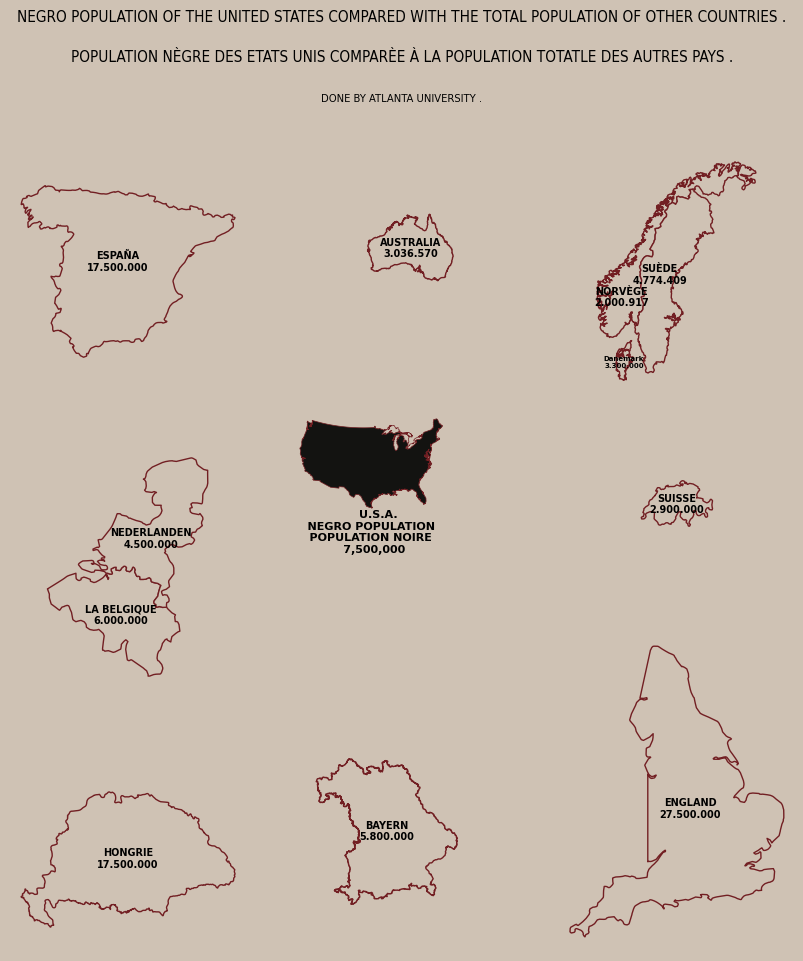

In [32]:
# Reproject to EPSG:9311
usa = gdf[gdf["id"] =="USA"]
usa = usa.to_crs(epsg=9311)

txt= """
        U.S.A.
    NEGRO POPULATION
    POPULATION NOIRE
      7,500,000
    """

# Drop USA from gdf
gdf2 = gdf[gdf["id"] !="USA"]

# Create figure
fig, ax = plt.subplots(figsize=(8, 10), facecolor="#cfc2b4")

# Set the position of the axes 
ax.set_position([0.01, 0.01, 0.98, 0.8])

# Hide axis
ax.axis("off")

# Create child axes
child_ax1 = ax.inset_axes([0., 0.7, 0.3, 0.3])
child_ax2 = ax.inset_axes([0.45, 0.73, 0.12, 0.3])
child_ax3 = ax.inset_axes([0.7, 0.7, 0.3, 0.3])

child_ax4 = ax.inset_axes([0., 0.33, 0.3, 0.3])
child_ax5 = ax.inset_axes([0.36, 0.51, 0.2, 0.2])
child_ax6 = ax.inset_axes([0.8, 0.51, 0.1, 0.1])

child_ax7 = ax.inset_axes([0., -0.05, 0.3, 0.33])
child_ax8 = ax.inset_axes([0.38, 0.05, 0.2, 0.2])
child_ax9 = ax.inset_axes([0.7, -0.05, 0.3, 0.5])

# List of child axes
child_axes = [
    child_ax1, child_ax2, child_ax3,
    child_ax4, child_ax5, child_ax6,
    child_ax7, child_ax8, child_ax9
]

# Remove child_ax5 from the list for the loop
plot_axes = [ax for ax in child_axes if ax is not child_ax5]

# Loop over ids and axes
for ax, (id_val, subset) in zip(plot_axes, gdf2.groupby("id", sort=False)):       
    
    # Plot polygons
    subset.plot(ax=ax, color="#cfc2b4", edgecolor="#721f23")
    
    # Add labels at centroids
    for i, row in subset.iterrows():

        if i == 2:
            xoffset = -3.5
            yoffset = -2.5
            fontsize = 7
        elif i == 3:
            xoffset = -1
            yoffset = 0.4
            fontsize = 7
        elif i == 4:
            xoffset = 0
            yoffset = 0
            fontsize = 5
        elif i == 6:
            xoffset = -0.15
            yoffset = -0.2
            fontsize = 7
        else:
            xoffset = 0
            yoffset = 0
            fontsize = 7
            
        centroid = row["centroid"]
        ax.text(
            centroid.x + xoffset,
            centroid.y + yoffset,
            f"{row['Country']}\n{row['Population']:,}".replace(",", "."),
            ha="center",
            va="center",
            fontsize=fontsize,            
            weight="bold"
            )
    # Hide axis
    ax.set_axis_off()

# Plot USA
usa.plot(ax=child_ax5, color="#131311", ec="#721f23", lw=0.5)
# Plot Great Lakes
lakes_gdf.plot(ax=child_ax5, color="#cfc2b4", ec="#721f23", lw=0.5)
# Hide axis
child_ax5.axis("off")

# Text annotation
child_ax5.text(0., -3.9e6, s=txt, size=8, weight="bold", ha="center")

# Title and subtitles
fig.text(0.5, 0.94, title, size=11, ha="center", fontstretch="ultra-condensed")
fig.text(0.5, 0.9, subtitle1, size=11, ha="center", fontstretch="ultra-condensed")
fig.text(0.5, 0.86, subtitle2, size=8, ha="center", fontstretch="ultra-condensed")

plt.show()

#plt.savefig("plate41.jpg")

In [33]:
import matplotlib.image as mpimg
from PIL import Image

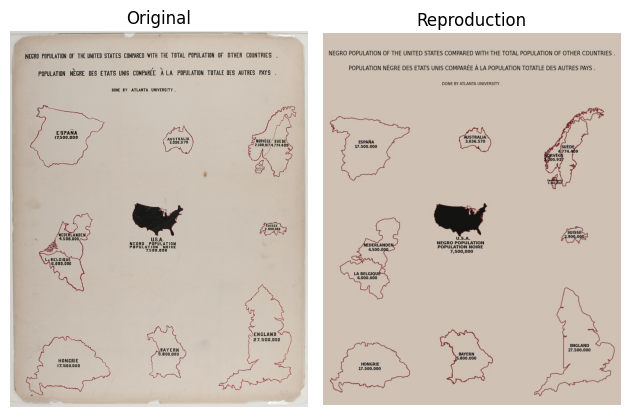

In [34]:
# Load images 
image1 = Image.open("original-plate-41.jpg")
image2 = Image.open("plate41.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate41sidebyside.png", dpi=300)